# Backpropagation in Multilayer Neural Networks

While we will primarily be working with high-level, abstract toolkits like Keras in this course, understanding how backpropagation works is absolutely essential to using neural networks. 

In this exercise, we will build our own backpropagation algorithm - working through each step, to ensure that we can follow it.

Just like in Lab 1, we'll be working with the MNIST dataset. We will load it and plot an example:

In [17]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_digits

digits = load_digits()

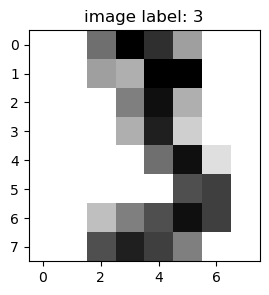

In [18]:
sample_index = 45
plt.figure(figsize=(3, 3))
plt.imshow(digits.images[sample_index], cmap=plt.cm.gray_r,
           interpolation='nearest')
plt.title("image label: %d" % digits.target[sample_index]);

### Preprocessing

Of course, we need to split our data into training and testing sets before we use it, just the same as in Lab 1:

In [19]:
from sklearn.model_selection import train_test_split

data = np.asarray(digits.data, dtype='float32')
target = np.asarray(digits.target, dtype='int32')

X_train, X_test, y_train, y_test = train_test_split(
    data, target, test_size=0.15, random_state=37)

# Numpy Implementation

## a) Logistic Regression

In this section we will implement a logistic regression model trainable with SGD using numpy. Here are the objectives:

- Implement the softmax function $\sigma(\mathbf{x})_i = \frac{e^{x_i}}{\sum_{j=1}^n e^{x_j}}$;
- Implement the negative log likelihood function $NLL(Y_{true}, Y_{pred}) = - \sum_{i=1}^{n}{y_{true, i} \cdot \log(y_{pred, i})}$;
- Train a logistic regression model on the MNIST dataset;
- Evaluate the model on the training and testing sets.

Before we get there, let's write a function that one-hot encodes the class labels:

In [20]:
def one_hot(n_classes, y):
    return np.eye(n_classes)[y]

In [21]:
one_hot(n_classes=10, y=3)

array([0., 0., 0., 1., 0., 0., 0., 0., 0., 0.])

In [22]:
one_hot(n_classes=10, y=[0, 4, 9, 1])

array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]])

### The softmax function

Now we will implement the softmax function. Recall that the softmax function is defined as follows:

$$
softmax(\mathbf{x}) = \frac{1}{\sum_{i=1}^{n}{e^{x_i}}}
\cdot
\begin{bmatrix}
  e^{x_1}\\\\
  e^{x_2}\\\\
  \vdots\\\\
  e^{x_n}
\end{bmatrix}
$$

This is implemented for you using numpy - we want to be able to apply the softmax function to a batch of samples at once, so we will use numpy's vectorized operations to do so.

Our method also handles _stability issues_ that can occur when the values in `X` are very large. We will subtract the maximum value from each row of `X` to avoid overflow in the exponentiation. This isn't part of the softmax function itself, but it's a useful trick to know about.

In [23]:
def softmax(X):
    X_max = np.max(X, axis=-1, keepdims=True)
    exp = np.exp(X - X_max) # Subtract the max to avoid overflow in the exponentiation
    return exp / np.sum(exp, axis=-1, keepdims=True)


Let's make sure that this works one vector at a time (and check that the components sum to one):

In [24]:
print(softmax([10, 2, -3]))

[9.99662391e-01 3.35349373e-04 2.25956630e-06]


When we are using our model to make predictions, we will want to be able to make predictions for multiple samples at once.
Let's make sure that our implementation of softmax works for a batch of samples:

In [25]:
X = np.array([[10, 2, -3],
              [-1, 5, -20]])
print(softmax(X))

[[9.99662391e-01 3.35349373e-04 2.25956630e-06]
 [2.47262316e-03 9.97527377e-01 1.38536042e-11]]


Probabilities should sum to 1:

In [26]:
print(np.sum(softmax([10, 2, -3])))

1.0


In [27]:
print("softmax of 2 vectors:")
X = np.array([[10, 2, -3],
              [-1, 5, -20]])
print(softmax(X))

softmax of 2 vectors:
[[9.99662391e-01 3.35349373e-04 2.25956630e-06]
 [2.47262316e-03 9.97527377e-01 1.38536042e-11]]


The sum of probabilities for each input vector of logits should some to 1:

In [28]:
print(np.sum(softmax(X), axis=1))

[1. 1.]


Now we will implement a function that, given the true one-hot encoded class `Y_true` and some predicted probabilities `Y_pred`, returns the negative log likelihood.

Recall that the negative log likelihood is defined as follows:

$$
NLL(Y_{true}, Y_{pred}) = - \sum_{i=1}^{n}{y_{true, i} \cdot \log(y_{pred, i})}
$$

For example, if we have $y_{true} = [1, 0, 0]$ and $y_{pred} = [0.99, 0.01, 0]$, then the negative log likelihood is $- \log(0.99) \approx 0.01$.

In [29]:
def nll(Y_true, Y_pred):
    Y_true = np.asarray(Y_true)
    Y_pred = np.asarray(Y_pred)

    # Ensure Y_pred doesn't have zero probabilities to avoid log(0)
    Y_pred = np.clip(Y_pred, 1e-15, 1 - 1e-15)

    # Calculate negative log likelihood
    loss = -np.sum(Y_true * np.log(Y_pred))
    return loss

# Make sure that it works for a simple sample at a time
print(nll([1, 0, 0], [.99, 0.01, 0]))

0.01005033585350145


We should see a very high value for this negative log likelihood, since the model is very confident that the third class is the correct one, but the true class is the first one:

In [30]:
print(nll([1, 0, 0], [0.01, 0.01, .98]))

4.605170185988091


Make sure that your implementation can compute the average negative log likelihood of a group of predictions: `Y_pred` and `Y_true` can therefore be past as 2D arrays:

In [31]:
# Check that the average NLL of the following 3 almost perfect
# predictions is close to 0
Y_true = np.array([[0, 1, 0],
                   [1, 0, 0],
                   [0, 0, 1]])

Y_pred = np.array([[0,   1,    0],
                   [.99, 0.01, 0],
                   [0,   0,    1]])

print(nll(Y_true, Y_pred))

0.010050335853503449


Now that we have our softmax and negative log likelihood functions, we can implement a logistic regression model. 
In this section, we have built the model for you, but you will need to complete a few key parts.

**YOUR TURN:**

1. Implement the `forward` method of the `LogisticRegression` class. This method should take in a batch of samples `X` and return the predicted probabilities for each class. You should use the softmax function that we implemented earlier.
2. Implement the `loss` method of the `LogisticRegression` class. This method take in the samples `X` and the true values `y` and return the average negative log likelihood of the predictions.

In [34]:
class LogisticRegression:

    def __init__(self, input_size, output_size):
        self.W = np.random.uniform(size=(input_size, output_size), high=0.1, low=-0.1)
        self.b = np.random.uniform(size=output_size, high=0.1, low=-0.1)
        self.output_size = output_size
        self.input_size = input_size

    def forward(self, X):
        """
        X: shape (N, D) or (D,)
        returns probabilities with shape (N, C) or (C,)
        """
        X = np.asarray(X, dtype=np.float32)
        single = (X.ndim == 1)
        if single:
            X = X[None, :]                 # (1, D)

        Z = X @ self.W + self.b            # (N, C)  bias broadcasts
        P = softmax(Z)                     # (N, C)

        return P[0] if single else P

    def predict(self, X):
        if len(X.shape) == 1:
            return np.argmax(self.forward(X))
        else:
            return np.argmax(self.forward(X), axis=1)

    def loss(self, X, y):
        """
        Average negative log-likelihood over the batch.
        X: (N, D) or (D,)
        y: (N,) int labels or scalar int
        """
        X = np.asarray(X, dtype=np.float32)
        y = np.asarray(y)

        P = self.forward(X)                            # (N, C) or (C,)
        if P.ndim == 1:                                # single sample
            Y_true = one_hot(self.output_size, int(y))
            return nll(Y_true, P)                      # scalar
        else:
            Y_true = one_hot(self.output_size, y.astype(int))  # (N, C)
            return nll(Y_true, P) / X.shape[0]         # average over N

    def grad_loss(self, X, y_true, y_pred):
        # expects X: (N, D), y_true/y_pred: (N, C)
        grad_W = X.T @ (y_pred - y_true) / X.shape[0]
        grad_b = np.sum(y_pred - y_true, axis=0) / X.shape[0]
        return grad_W, grad_b


In [35]:
# Build a model and test its forward inference
n_features = X_train.shape[1]
n_classes = len(np.unique(y_train))
lr = LogisticRegression(n_features, n_classes)

We can evaluate the model on an example, visualizing the prediction probabilities:

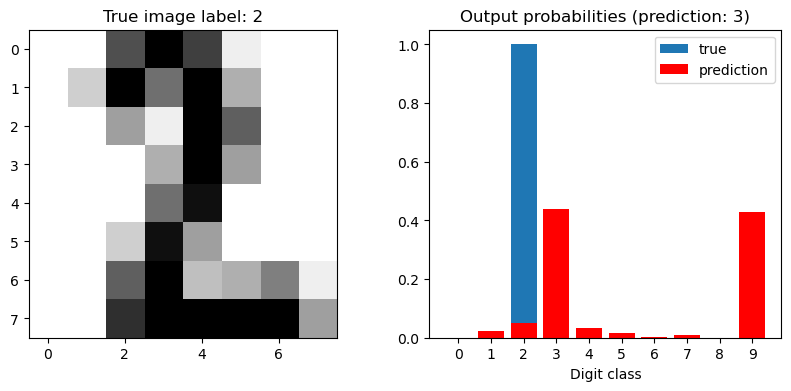

In [36]:
def plot_prediction(model, sample_idx=0, classes=range(10)):
    fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

    ax0.imshow(X_test[sample_idx:sample_idx+1].reshape(8, 8),
               cmap=plt.cm.gray_r, interpolation='nearest')
    ax0.set_title("True image label: %d" % y_test[sample_idx]);


    ax1.bar(classes, one_hot(len(classes), y_test[sample_idx]), label='true')
    ax1.bar(classes, model.forward(X_test[sample_idx]), label='prediction', color="red")
    ax1.set_xticks(classes)
    prediction = model.predict(X_test[sample_idx])
    ax1.set_title('Output probabilities (prediction: %d)'
                  % prediction)
    ax1.set_xlabel('Digit class')
    ax1.legend()

plot_prediction(lr, sample_idx=0)
    

Now it's time to start training! We will train for a single epoch, and then evaluate the model on the training and testing sets. Read through the following and make sure that you understand what we are doing here.

In [37]:
lr = LogisticRegression(input_size=X_train.shape[1], output_size=10)

learning_rate = 0.01

for i in range(len(X_train)):
    # Get the current sample and corresponding label
    x = X_train[i:i+1]  # Reshape to keep the batch dimension
    y = y_train[i:i+1]  # Reshape to keep the batch dimension

    # Compute the forward pass and the gradient of the loss with respect to W and b
    y_pred = lr.forward(x)
    grad_W, grad_b = lr.grad_loss(x, one_hot(lr.output_size, y), y_pred)

    # Update the weights and biases
    lr.W -= learning_rate * grad_W
    lr.b -= learning_rate * grad_b

    # Print the average negative log likelihood every 100 steps (avoid empty slice at i==0)
    if i > 0 and i % 100 == 0:
        avg_nll = lr.loss(X_train[max(0, i-100):i], y_train[max(0, i-100):i])
        print("Average NLL over the last 100 samples at step %d: %0.f" % (i, avg_nll))


Average NLL over the last 100 samples at step 100: 4
Average NLL over the last 100 samples at step 200: 3
Average NLL over the last 100 samples at step 300: 1
Average NLL over the last 100 samples at step 400: 2
Average NLL over the last 100 samples at step 500: 2
Average NLL over the last 100 samples at step 600: 1
Average NLL over the last 100 samples at step 700: 2
Average NLL over the last 100 samples at step 800: 1
Average NLL over the last 100 samples at step 900: 1
Average NLL over the last 100 samples at step 1000: 2
Average NLL over the last 100 samples at step 1100: 2
Average NLL over the last 100 samples at step 1200: 2
Average NLL over the last 100 samples at step 1300: 1
Average NLL over the last 100 samples at step 1400: 0
Average NLL over the last 100 samples at step 1500: 1


Evaluate the trained model on the first example:

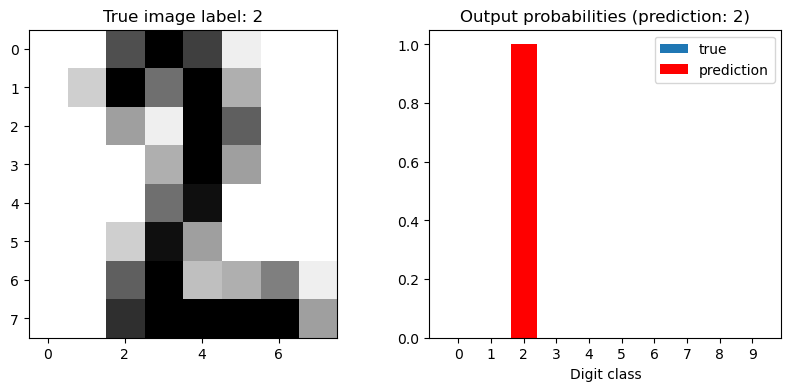

In [38]:
plot_prediction(lr, sample_idx=0)

## b) Feedforward Multilayer

The objective of this section is to implement the backpropagation algorithm (SGD with the chain rule) on a single layer neural network using the sigmoid activation function.

Now it's your turn to

- Implement the `sigmoid` and its element-wise derivative `dsigmoid` functions:

$$
sigmoid(x) = \frac{1}{1 + e^{-x}}
$$

$$
dsigmoid(x) = sigmoid(x) \cdot (1 - sigmoid(x))
$$

Remember that you can use your `sigmoid` function inside your `dsigmoid` function.

Just like with our softmax function, we also want to make sure that we don't run into stability issues with our sigmoid function. We will use `np.clip` to ensure that the input to the sigmoid function is not too large or too small.

In [40]:
import numpy as np

def sigmoid(X):
    # Clip to avoid overflow/underflow in exp
    X = np.clip(X, -500, 500)
    return 1.0 / (1.0 + np.exp(-X))

def dsigmoid(X):
    s = sigmoid(X)
    return s * (1.0 - s)


Now it's your turn to complete the neural network code, so that we can train it on the MNIST dataset.

Some parts have been completed for you already. Often, you'll be able to refer back to the code from the previous section to help you complete the code in this section.

In [42]:
import numpy as np

# Make sure these are defined ABOVE the class
def sigmoid(X):
    X = np.clip(X, -500, 500)
    return 1.0 / (1.0 + np.exp(-X))

def dsigmoid(X):
    s = sigmoid(X)
    return s * (1.0 - s)

def one_hot(n_classes, y):
    y = np.asarray(y)
    return np.eye(n_classes)[y]

class NeuralNet:
    """MLP with 1 hidden layer (sigmoid) and sigmoid outputs (one-vs-rest)."""

    def __init__(self, input_size, hidden_size, output_size):
        self.W_h = np.random.uniform(low=-0.1, high=0.1, size=(input_size, hidden_size))
        self.b_h = np.random.uniform(low=-0.1, high=0.1, size=(hidden_size,))
        self.W_o = np.random.uniform(low=-0.1, high=0.1, size=(hidden_size, output_size))
        self.b_o = np.random.uniform(low=-0.1, high=0.1, size=(output_size,))

        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size

    @staticmethod
    def _ensure_2d(A):
        A = np.asarray(A, dtype=np.float32)
        return A if A.ndim == 2 else A[None, :]

    def forward_hidden(self, X):
        X = self._ensure_2d(X)               # (N, D)
        self.Z_h = X @ self.W_h + self.b_h   # (N, H)
        H = sigmoid(self.Z_h)                # (N, H)
        return H

    def forward_output(self, H):
        H = self._ensure_2d(H)               # (N, H)
        self.Z_o = H @ self.W_o + self.b_o   # (N, C)
        Y = sigmoid(self.Z_o)                # (N, C)
        return Y

    def forward(self, X):
        H = self.forward_hidden(X)           # (N, H)
        Y = self.forward_output(H)           # (N, C)
        return Y

    def loss(self, X, y):
        """
        Binary cross-entropy (per class) averaged over the batch.
        Works with class indices y (not one-hot).
        """
        X = self._ensure_2d(X)
        y = np.asarray(y).astype(int)

        Y_pred = self.forward(X)                                 # (N, C)
        Y_true = one_hot(self.output_size, y)                    # (N,) -> (N, C)

        eps = 1e-15
        P = np.clip(Y_pred, eps, 1.0 - eps)
        bce = -(Y_true * np.log(P) + (1.0 - Y_true) * np.log(1.0 - P))  # (N, C)
        return np.mean(np.sum(bce, axis=1))                      # scalar

    def grad_loss(self, X, y_true):
        """
        Uses your derivation:
          error_o = y_pred - y_true
          grad_W_o = Z_h^T @ error_o
          grad_b_o = sum(error_o)
          error_h = (error_o @ W_o^T) * dsigmoid(Z_h)
          grad_W_h = X^T @ error_h
          grad_b_h = sum(error_h)
        """
        X = self._ensure_2d(X)                                   # (N, D)
        y_true = one_hot(self.output_size, y_true.astype(int))   # (N,) -> (N, C)
        y_pred = self.forward(X)                                 # (N, C)

        error_o = y_pred - y_true                                # (N, C)

        grad_W_o = self.Z_h.T @ error_o                          # (H, C)
        grad_b_o = np.sum(error_o, axis=0)                       # (C,)

        error_h = (error_o @ self.W_o.T) * dsigmoid(self.Z_h)    # (N, H)

        grad_W_h = X.T @ error_h                                 # (D, H)
        grad_b_h = np.sum(error_h, axis=0)                       # (H,)

        return {"W_h": grad_W_h, "b_h": grad_b_h, "W_o": grad_W_o, "b_o": grad_b_o}

    def train(self, x, y, learning_rate):
        x = np.asarray(x)
        if x.ndim == 1:
            x = x[None, :]                                       # (1, D)
        grads = self.grad_loss(x, y)
        self.W_h -= learning_rate * grads["W_h"]
        self.b_h -= learning_rate * grads["b_h"]
        self.W_o -= learning_rate * grads["W_o"]
        self.b_o -= learning_rate * grads["b_o"]

    def predict(self, X):
        Y = self.forward(X)                                      # (N, C) or (1, C)
        return np.argmax(Y, axis=1) if Y.ndim == 2 else int(np.argmax(Y))

    def accuracy(self, X, y):
        return np.mean(self.predict(X) == y)


Once the code is written, we can test our model on a single sample:

In [43]:
n_hidden = 10
model = NeuralNet(n_features, n_hidden, n_classes)

In [44]:
model.loss(X_train, y_train)

np.float64(7.056291840591728)

In [45]:
model.accuracy(X_train, y_train)

np.float64(0.09692206941715782)

In [51]:
ax1.bar(classes,
        np.asarray(model.forward(X_test[sample_idx])).ravel(),   # <-- flatten to (C,)
        label='prediction',
        color="red")

NameError: name 'ax1' is not defined

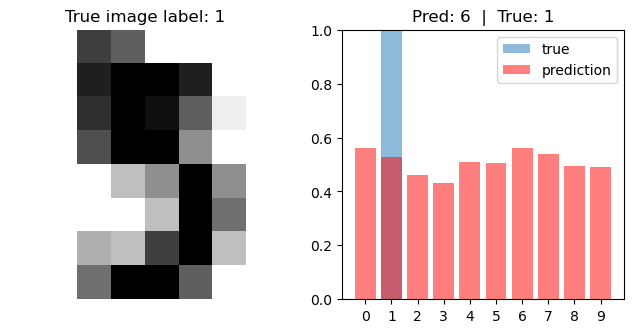

In [50]:
plot_prediction(model, sample_idx=5)

And now it's time to train!

In [52]:
losses, accuracies, accuracies_test = [], [], []
losses.append(model.loss(X_train, y_train))
accuracies.append(model.accuracy(X_train, y_train))
accuracies_test.append(model.accuracy(X_test, y_test))

print("Random init: train loss: %0.5f, train acc: %0.3f, test acc: %0.3f"
      % (losses[-1], accuracies[-1], accuracies_test[-1]))

for epoch in range(15):
    for i, (x, y) in enumerate(zip(X_train, y_train)):
        model.train(x, y, 0.001)

    losses.append(model.loss(X_train, y_train))
    accuracies.append(model.accuracy(X_train, y_train))
    accuracies_test.append(model.accuracy(X_test, y_test))
    print("Epoch #%d, train loss: %0.5f, train acc: %0.3f, test acc: %0.3f"
          % (epoch + 1, losses[-1], accuracies[-1], accuracies_test[-1]))

Random init: train loss: 7.05629, train acc: 0.097, test acc: 0.096
Epoch #1, train loss: 3.02132, train acc: 0.389, test acc: 0.363
Epoch #2, train loss: 2.55529, train acc: 0.672, test acc: 0.611
Epoch #3, train loss: 2.11794, train acc: 0.766, test acc: 0.752
Epoch #4, train loss: 1.77231, train acc: 0.817, test acc: 0.796
Epoch #5, train loss: 1.52537, train acc: 0.856, test acc: 0.826
Epoch #6, train loss: 1.34290, train acc: 0.879, test acc: 0.863
Epoch #7, train loss: 1.20068, train acc: 0.894, test acc: 0.878
Epoch #8, train loss: 1.08552, train acc: 0.906, test acc: 0.885
Epoch #9, train loss: 0.99064, train acc: 0.920, test acc: 0.900
Epoch #10, train loss: 0.92445, train acc: 0.923, test acc: 0.919
Epoch #11, train loss: 0.89555, train acc: 0.910, test acc: 0.915
Epoch #12, train loss: 0.86417, train acc: 0.911, test acc: 0.911
Epoch #13, train loss: 0.82239, train acc: 0.914, test acc: 0.911
Epoch #14, train loss: 0.77677, train acc: 0.914, test acc: 0.919
Epoch #15, train 

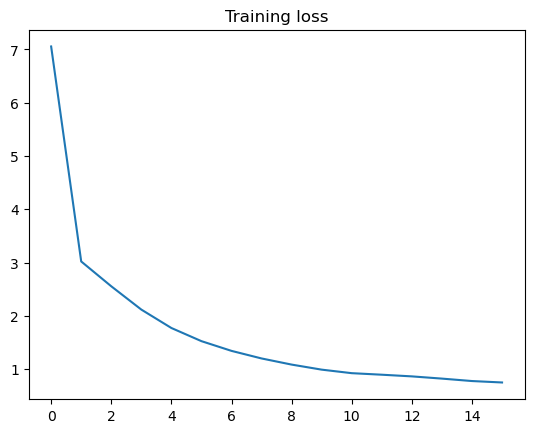

In [53]:
plt.plot(losses)
plt.title("Training loss");

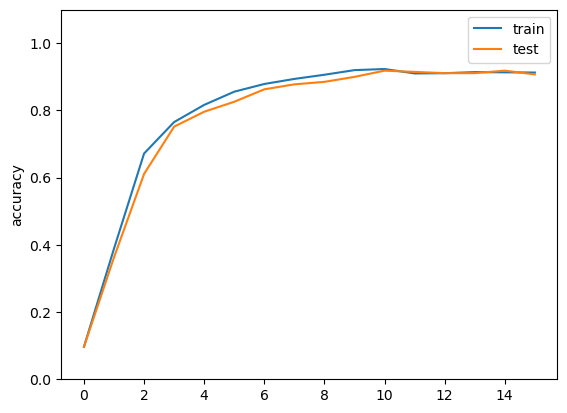

In [54]:
plt.plot(accuracies, label='train')
plt.plot(accuracies_test, label='test')
plt.ylim(0, 1.1)
plt.ylabel("accuracy")
plt.legend(loc='best');

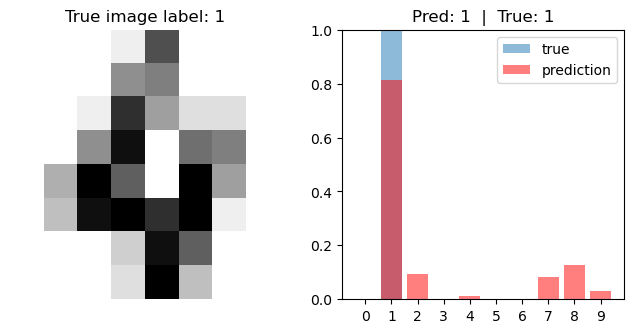

In [55]:
plot_prediction(model, sample_idx=4)

## c) Exercises

### Look at worst prediction errors

- Use numpy to find test samples for which the model made the worst predictions,
- Use the `plot_prediction` to look at the model predictions on those,
- Would you have done any better?

Most-confident wrong IDs: [np.int64(170), np.int64(34), np.int64(9), np.int64(45), np.int64(99), np.int64(105), np.int64(121), np.int64(107), np.int64(249)]
Lowest true-prob wrong IDs: [np.int64(107), np.int64(69), np.int64(99), np.int64(170), np.int64(33), np.int64(55), np.int64(87), np.int64(9), np.int64(67)]


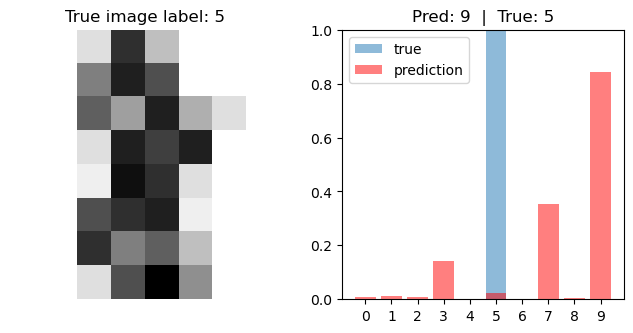

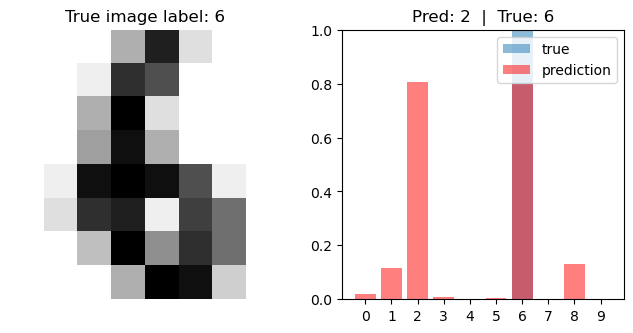

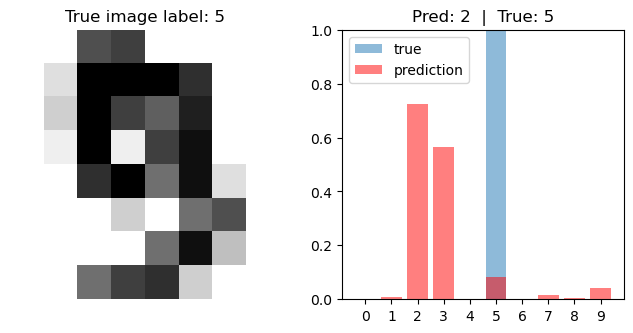

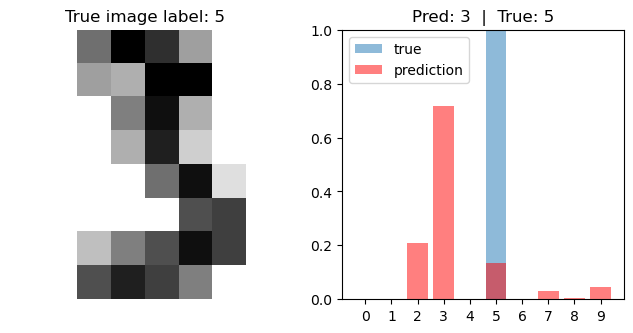

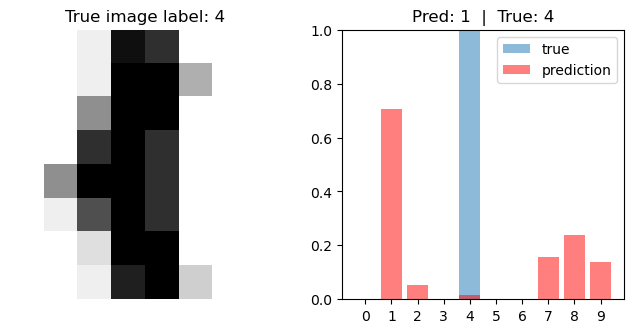

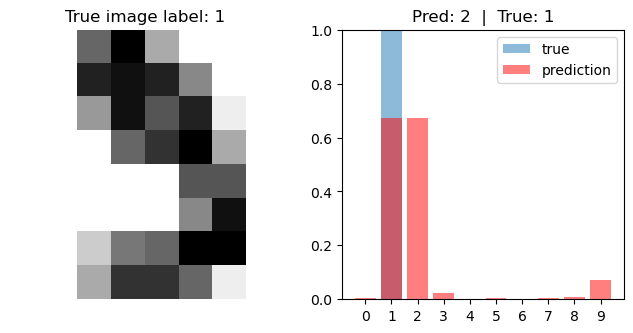

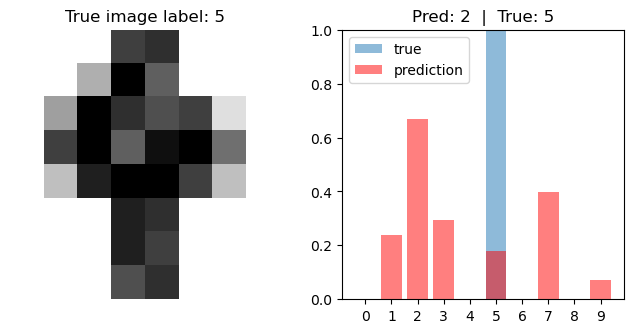

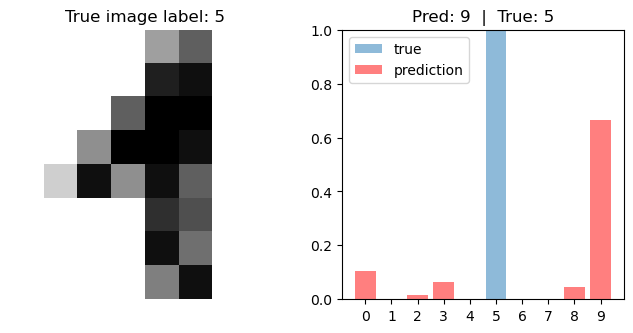

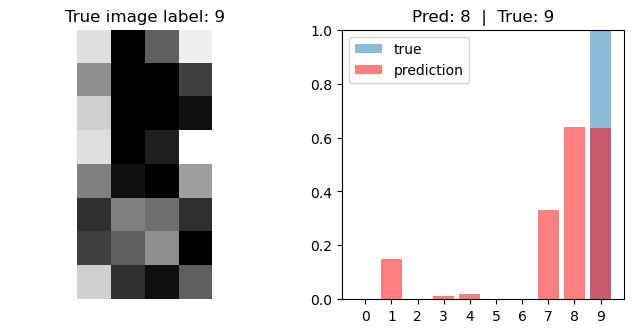

In [57]:
# Your code here
import numpy as np

def collect_predictions(m, X):
    # Stack per-sample prediction vectors into (N, C)
    Y = [np.asarray(m.forward(x), dtype=float).reshape(-1) for x in X]
    return np.vstack(Y)

def worst_errors_indices(m, X, y, top_k=9):
    Y_pred = collect_predictions(m, X)          # (N, C)
    y_true = y.astype(int)
    N, C = Y_pred.shape

    pred_cls = Y_pred.argmax(axis=1)
    correct = (pred_cls == y_true)
    wrong_idx = np.where(~correct)[0]
    if wrong_idx.size == 0:
        return [], []

    pred_conf = Y_pred[np.arange(N), pred_cls]        # confidence in predicted class
    true_prob = Y_pred[np.arange(N), y_true]          # prob assigned to true class

    # 1) Most-confident wrong: sort wrong by predicted confidence (desc)
    mcw_sorted = wrong_idx[np.argsort(pred_conf[wrong_idx])[::-1]]

    # 2) Lowest true-class probability among wrong (asc)
    low_true_sorted = wrong_idx[np.argsort(true_prob[wrong_idx])]

    return list(mcw_sorted[:top_k]), list(low_true_sorted[:top_k])

# --- Choose which model to inspect: m = model  (logistic regression) or m = nn (MLP) ---
m = model   # or: m = nn

mcw, low_true = worst_errors_indices(m, X_test, y_test, top_k=9)
print("Most-confident wrong IDs:", mcw)
print("Lowest true-prob wrong IDs:", low_true)

# Visualize (use your existing helper)
for idx in mcw:
    plot_prediction(m, sample_idx=idx)

for idx in low_true:
    plot_prediction


### Hyper parameters settings

- Experiment with different hyperparameters:
  - learning rate,
  - size of hidden layer,
  - implement the support for a second hidden layer.
  - What is the best test accuracy you can get?

In [59]:
import numpy as np
from math import sqrt

# ---------- helpers ----------
def glorot_uniform(fan_in, fan_out):
    limit = sqrt(6.0 / (fan_in + fan_out))
    W = np.random.uniform(low=-limit, high=limit, size=(fan_in, fan_out)).astype(np.float32)
    b = np.zeros((fan_out,), dtype=np.float32)
    return W, b

def _ensure_2d(A):
    A = np.asarray(A, dtype=np.float32)
    return A if A.ndim == 2 else A[None, :]

def bce_loss(y_true, y_pred, eps=1e-15):
    P = np.clip(y_pred, eps, 1.0 - eps)
    return -np.sum(y_true * np.log(P) + (1.0 - y_true) * np.log(1.0 - P), axis=1)

# ---------- model ----------
class MLP:
    """1 or 2 hidden layers, sigmoid activations, sigmoid outputs (one-vs-rest)."""
    def __init__(self, input_size, hidden1, output_size, hidden2=None):
        self.input_size = input_size
        self.hidden1 = hidden1
        self.hidden2 = hidden2
        self.output_size = output_size

        self.W1, self.b1 = glorot_uniform(input_size, hidden1)
        if hidden2 is not None:
            self.W2, self.b2 = glorot_uniform(hidden1, hidden2)
            fan = hidden2
        else:
            fan = hidden1
        self.Wo, self.bo = glorot_uniform(fan, output_size)

        # caches for backprop
        self.Z1 = self.H1 = None
        self.Z2 = self.H2 = None
        self.Zo = self.Y  = None

    def forward(self, X):
        X = _ensure_2d(X)                                    # (N, D)
        self.Z1 = X @ self.W1 + self.b1                      # (N, H1)
        self.H1 = sigmoid(self.Z1)
        if self.hidden2 is not None:
            self.Z2 = self.H1 @ self.W2 + self.b2            # (N, H2)
            self.H2 = sigmoid(self.Z2)
            self.Zo = self.H2 @ self.Wo + self.bo            # (N, C)
        else:
            self.Zo = self.H1 @ self.Wo + self.bo            # (N, C)
        self.Y = sigmoid(self.Zo)                            # (N, C)
        return self.Y

    def loss(self, X, y):
        X = _ensure_2d(X)
        y = np.asarray(y, dtype=int)
        Y_true = np.eye(self.output_size, dtype=np.float32)[y]
        Y_pred = self.forward(X)
        return float(np.mean(bce_loss(Y_true, Y_pred)))

    def grad_batch(self, X, y):
        """Gradients on a mini-batch."""
        X = _ensure_2d(X)                                    # (B, D)
        y = np.asarray(y, dtype=int)
        B = X.shape[0]
        Y_true = np.eye(self.output_size, dtype=np.float32)[y]  # (B, C)
        Y_pred = self.forward(X)                                # (B, C)

        # output layer
        dZo = (Y_pred - Y_true)                                # (B, C)
        if self.hidden2 is not None:
            H_top = self.H2
        else:
            H_top = self.H1
        gWo = H_top.T @ dZo                                    # (top, C)
        gbo = np.sum(dZo, axis=0)                              # (C,)

        # backprop into hidden(s)
        dH_top = dZo @ self.Wo.T                               # (B, top)

        if self.hidden2 is not None:
            dZ2 = dH_top * dsigmoid(self.Z2)                   # (B, H2)
            gW2 = self.H1.T @ dZ2                              # (H1, H2)
            gb2 = np.sum(dZ2, axis=0)                          # (H2,)
            dH1 = dZ2 @ self.W2.T                              # (B, H1)
        else:
            gW2 = gb2 = None
            dH1 = dH_top

        dZ1 = dH1 * dsigmoid(self.Z1)                          # (B, H1)
        gW1 = X.T @ dZ1                                        # (D, H1)
        gb1 = np.sum(dZ1, axis=0)                              # (H1,)

        grads = {"W1": gW1/B, "b1": gb1/B, "Wo": gWo/B, "bo": gbo/B}
        if self.hidden2 is not None:
            grads.update({"W2": gW2/B, "b2": gb2/B})
        return grads

# ---------- training with SGD + optional momentum, early stopping ----------
def train_model(input_size, output_size, hidden1, hidden2, lr=0.1, momentum=0.9,
                epochs=60, batch_size=64, clip_norm=None, val_split=0.15, seed=42):
    rng = np.random.default_rng(seed)
    # split train into train/val
    N = X_train.shape[0]
    idx = np.arange(N)
    rng.shuffle(idx)
    val_n = int(val_split * N)
    val_idx, tr_idx = idx[:val_n], idx[val_n:]
    X_tr, y_tr = X_train[tr_idx], y_train[tr_idx]
    X_val, y_val = X_train[val_idx], y_train[val_idx]

    net = MLP(input_size, hidden1, output_size, hidden2)
    # momentum buffers
    v = {k: np.zeros_like(getattr(net, k)) for k in ["W1", "b1", "Wo", "bo"]}
    if hidden2 is not None:
        v.update({"W2": np.zeros_like(net.W2), "b2": np.zeros_like(net.b2)})

    best = {"val_loss": np.inf, "state": None, "epoch": -1}
    patience, wait = 8, 0

    for ep in range(epochs):
        # shuffle batches
        perm = rng.permutation(X_tr.shape[0])
        for i in range(0, X_tr.shape[0], batch_size):
            sel = perm[i:i+batch_size]
            grads = net.grad_batch(X_tr[sel], y_tr[sel])

            # (optional) gradient clipping
            if clip_norm is not None:
                total = 0.0
                for g in grads.values():
                    total += float(np.sum(g*g))
                total = sqrt(total)
                if total > clip_norm and total > 0:
                    scale = clip_norm / total
                    grads = {k: g*scale for k, g in grads.items()}

            # SGD + momentum update
            for name, g in grads.items():
                v[name] = momentum * v[name] + (1.0 - momentum) * g
                param = getattr(net, name)
                setattr(net, name, param - lr * v[name])

        # early-stopping on val loss
        vloss = net.loss(X_val, y_val)
        if vloss < best["val_loss"] - 1e-6:
            best["val_loss"] = vloss
            best["epoch"] = ep
            # snapshot weights
            best["state"] = {
                "W1": net.W1.copy(), "b1": net.b1.copy(),
                "Wo": net.Wo.copy(), "bo": net.bo.copy()
            }
            if hidden2 is not None:
                best["state"].update({"W2": net.W2.copy(), "b2": net.b2.copy()})
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    # restore best weights
    if best["state"] is not None:
        for name, arr in best["state"].items():
            setattr(net, name, arr)

    # final metrics
    def acc_fn(m, X, y):
        P = m.forward(X)
        preds = np.argmax(P, axis=1)
        return float(np.mean(preds == y))

    test_acc = acc_fn(net, X_test, y_test)
    val_acc  = acc_fn(net, X_train[val_idx], y_train[val_idx])
    train_acc= acc_fn(net, X_train[tr_idx], y_train[tr_idx])
    return {
        "net": net,
        "lr": lr,
        "h1": hidden1,
        "h2": hidden2,
        "val_loss": best["val_loss"],
        "val_acc": val_acc,
        "train_acc": train_acc,
        "test_acc": test_acc,
        "best_epoch": best["epoch"]
    }

# ---------- grid search ----------
search_space = {
    "lr":   [0.5, 0.1, 0.05],
    "h1":   [32, 64, 128],
    "h2":   [None, 64],     # None = 1 hidden layer; 64 = 2 hidden layers
}
results = []
for lr in search_space["lr"]:
    for h1 in search_space["h1"]:
        for h2 in search_space["h2"]:
            res = train_model(
                input_size=64, output_size=10,
                hidden1=h1, hidden2=h2,
                lr=lr, momentum=0.9,
                epochs=80, batch_size=64,
                clip_norm=5.0, val_split=0.15, seed=42
            )
            print(f"lr={lr:<4} h1={h1:<3} h2={str(h2):<4} | "
                  f"val_acc={res['val_acc']:.3f} test_acc={res['test_acc']:.3f} (best@{res['best_epoch']})")
            results.append(res)

# pick best by validation accuracy
best = max(results, key=lambda r: (r["val_acc"], -r["val_loss"]))
print("\nBest config:",
      f"lr={best['lr']}, h1={best['h1']}, h2={best['h2']} | "
      f"train={best['train_acc']:.3f}, val={best['val_acc']:.3f}, test={best['test_acc']:.3f} (best@{best['best_epoch']})")


C:\Users\Papi\AppData\Local\Temp\ipykernel_1344\2054908014.py:6: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-X))


lr=0.5  h1=32  h2=None | val_acc=0.961 test_acc=0.963 (best@46)
lr=0.5  h1=32  h2=64   | val_acc=0.969 test_acc=0.978 (best@36)
lr=0.5  h1=64  h2=None | val_acc=0.978 test_acc=0.974 (best@68)
lr=0.5  h1=64  h2=64   | val_acc=0.974 test_acc=0.981 (best@30)
lr=0.5  h1=128 h2=None | val_acc=0.983 test_acc=0.970 (best@65)
lr=0.5  h1=128 h2=64   | val_acc=0.983 test_acc=0.985 (best@65)
lr=0.1  h1=32  h2=None | val_acc=0.961 test_acc=0.956 (best@79)
lr=0.1  h1=32  h2=64   | val_acc=0.961 test_acc=0.959 (best@79)
lr=0.1  h1=64  h2=None | val_acc=0.978 test_acc=0.978 (best@79)
lr=0.1  h1=64  h2=64   | val_acc=0.974 test_acc=0.978 (best@79)
lr=0.1  h1=128 h2=None | val_acc=0.983 test_acc=0.978 (best@77)
lr=0.1  h1=128 h2=64   | val_acc=0.969 test_acc=0.978 (best@77)
lr=0.05 h1=32  h2=None | val_acc=0.943 test_acc=0.963 (best@79)
lr=0.05 h1=32  h2=64   | val_acc=0.961 test_acc=0.967 (best@79)
lr=0.05 h1=64  h2=None | val_acc=0.974 test_acc=0.978 (best@79)
lr=0.05 h1=64  h2=64   | val_acc=0.961 t